In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Egor\Downloads\marketing_campaign.csv", sep = "\t")

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
data.isnull().sum()                 # количество пропусков в каждой колонке

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

В колонке доходов видим, что есть 24 пропуска, остальные колонки заполнены полностью

In [5]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


<Axes: xlabel='Year_Birth'>

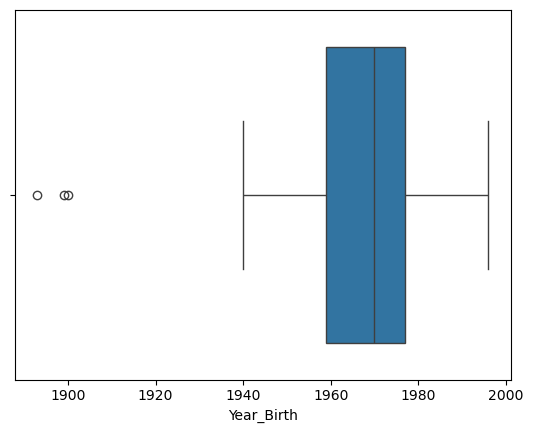

In [6]:
sns.boxplot(x=data['Year_Birth'])

Чтобы сделать опеределение возраста в дальнейшем более наглядным и удобным, заменим год рождения на возраст

 По каждому клиенту у нас есть дата регистрации в Dt_Customer, будет полезно использовать эту информацию как точку расчета его возраста

In [7]:
import datetime

#т.к. дата изначально не в том формате что нужен модулю datetime, переводим её в d-m-Y
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y', errors='coerce')

#удаляем строки, где дата не преобразовалась
data = data.dropna(subset=['Dt_Customer'])
data['Age'] = data['Dt_Customer'].dt.year - data['Year_Birth']

#Year_Birth и Dt_Customer больше не понадобятся, для чистоты таблицы их можно удалить
data.drop('Year_Birth', axis=1, inplace=True)
data.drop('Dt_Customer', axis=1, inplace=True)

#Перемещаем Age в удобное место, после Teenhome
age_col = data.pop('Age')
data.insert(6, 'Age', age_col)

Т.к. нам неинтересна информация о том, в какую из маркетинговых кампаний откликнулся клиент, объединим все эти колонки в одну, которая покажет, откликнулся ли клиент вообще

In [8]:
#список колонок, которые объединим
campaign_cols = ['Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

#создаём новую колонку — 1, если хотя бы одна из них равна 1
data['overall_response'] = data[campaign_cols].any(axis=1).astype(int)

#удаляем лишние колонки
data.drop('AcceptedCmp1', axis=1, inplace=True)
data.drop('AcceptedCmp2', axis=1, inplace=True)
data.drop('AcceptedCmp3', axis=1, inplace=True)
data.drop('AcceptedCmp4', axis=1, inplace=True)
data.drop('AcceptedCmp5', axis=1, inplace=True)
data.drop('Response', axis=1, inplace=True)

#ID также ни на что не влияет, от него можно избавиться
data.drop("ID", axis=1, inplace=True)

In [10]:
#Z_CostContact и Z_Revenue технические переменные, в нашей работе бесполезны, удаляем
data.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [11]:
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Age,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,overall_response
0,Graduation,Single,58138.0,0,0,55,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,Graduation,Single,46344.0,1,1,60,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,Graduation,Together,71613.0,0,0,48,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,Graduation,Together,26646.0,1,0,30,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,PhD,Married,58293.0,1,0,33,94,173,43,118,46,27,15,5,5,3,6,5,0,0


Далее я занялся поиском и обработкой выбросов, в данном случае наиболее удобным инструментом оказался "ящик с усами"

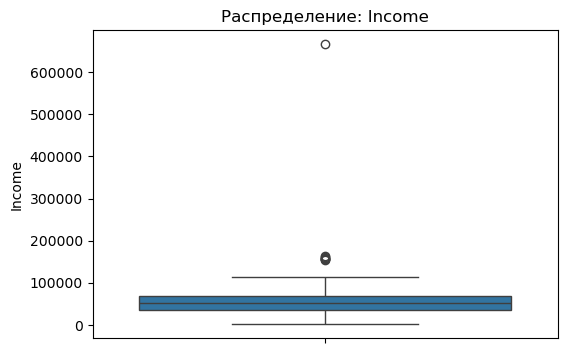

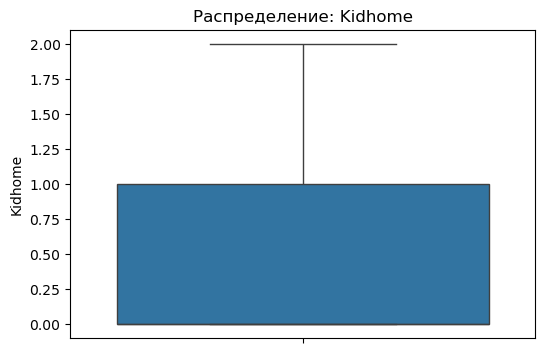

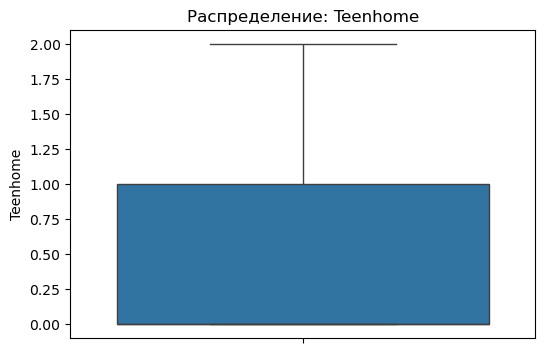

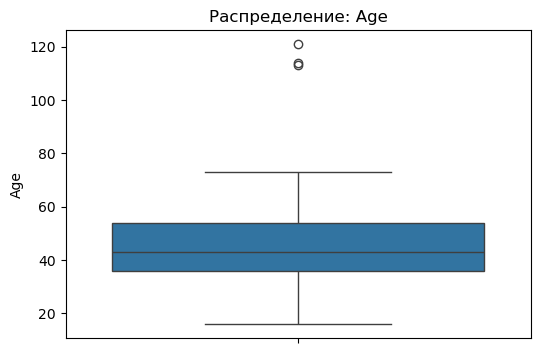

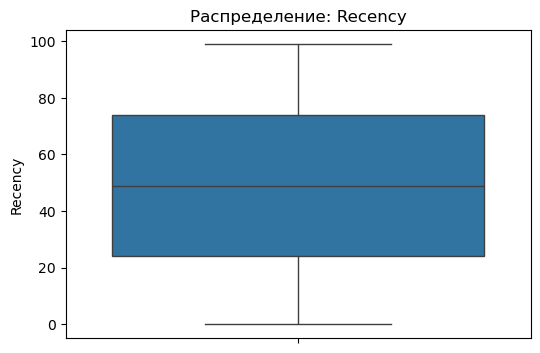

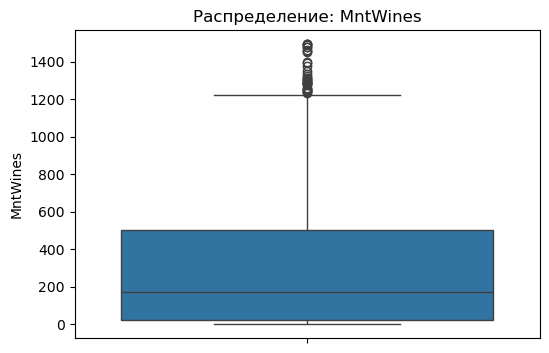

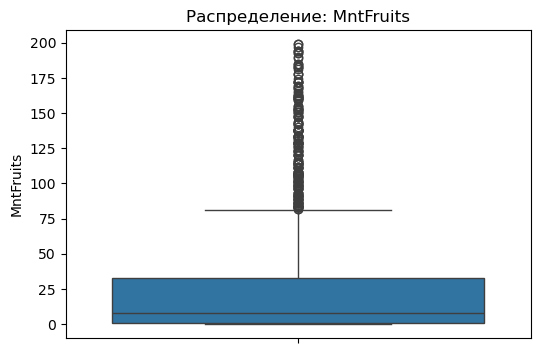

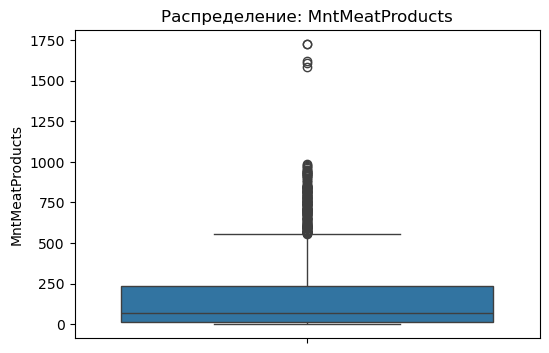

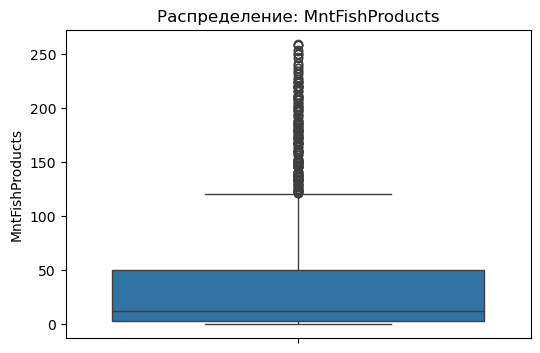

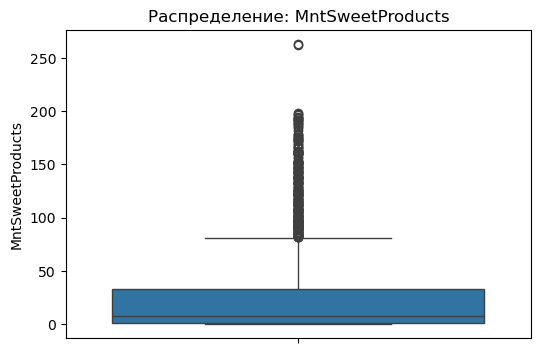

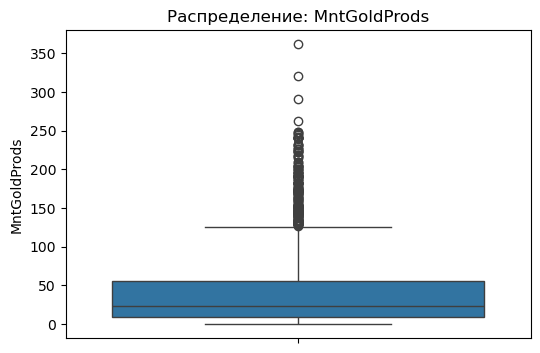

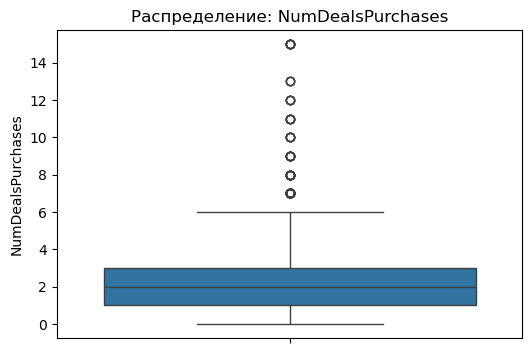

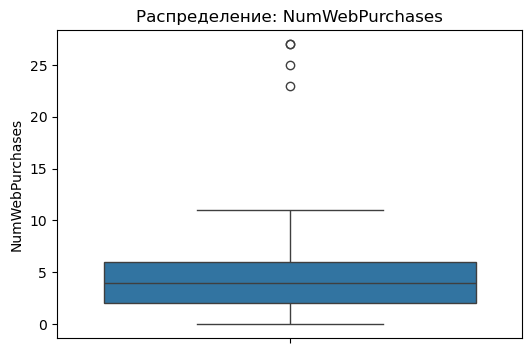

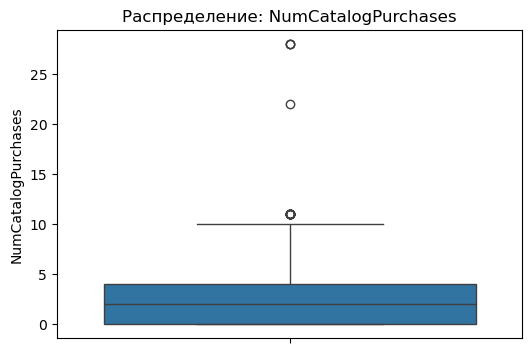

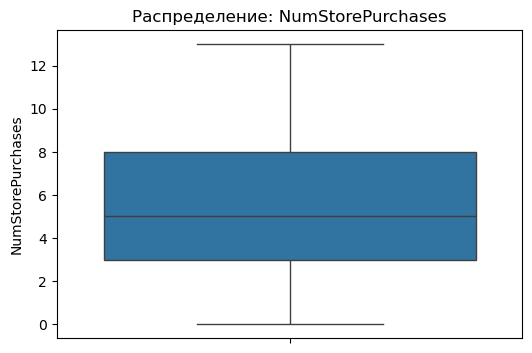

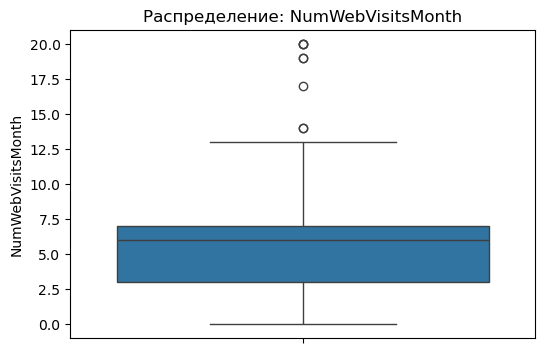

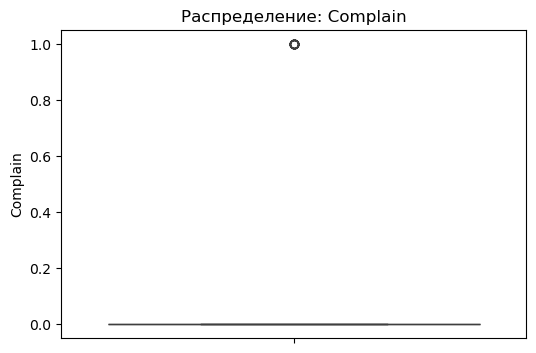

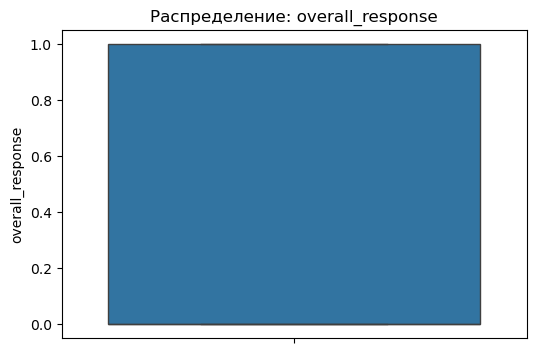

In [14]:
# Только числовые колонки
numeric_cols = data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data[col])
    plt.title(f'Распределение: {col}')
    plt.show()

In [15]:
#самый верхний выброс дохода кажется нереалистичным и его лучше отсеять
data = data[data['Income'] <= 200000]
#возраст регистрации выше 100 также является нереалистичным исключением
data = data[data['Age'] <= 100]

Остальные данные пока что трогать не будем, т.к. они могут быть полезны для сегментации